In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import random
import os.path as osp

from rdkit import Chem
import deepchem as dc
from deepchem.feat.smiles_tokenizer import BasicSmilesTokenizer
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
import torch_geometric.transforms as T
from torch_geometric.utils import negative_sampling, convert, to_dense_adj,structured_negative_sampling
from torch_geometric.nn import GCNConv, SAGEConv
from torch_geometric.nn.conv import MessagePassing

import torch
import torch.nn.functional as F
from torch.optim.lr_scheduler import ExponentialLR,MultiplicativeLR
from torch import Tensor
from torch.utils.data import DataLoader

from gensim.models import word2vec
from gensim.models import Word2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import pickle

from mol2vec.features import mol2alt_sentence, mol2sentence, MolSentence, DfVec
import torch
from sklearn.metrics import roc_auc_score ,auc,precision_recall_curve,f1_score

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
/home/giobbi/DDI_LLM_repo/DDI_with_ML/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
/home/giobbi/DDI_LLM_repo/DDI_with_ML/.venv/lib/python3.10/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing

# Interaction Data

In [2]:
DDI_graph = pd.read_csv('https://raw.githubusercontent.com/liiniix/BioSNAP/master/ChCh-Miner/ChCh-Miner_durgbank-chem-chem.tsv', sep='\t')
DDI_graph.rename(columns={'Drug1': 'src', 'Drug2': 'dst'}, inplace=True)
DrugIDs_in_graph = np.unique(DDI_graph.values) # there are 1514 unique drugs in the graph

In [3]:
G = nx.from_pandas_edgelist(DDI_graph, 'src', 'dst')

# Smiles

In [5]:
drugsSMILES = pd.read_csv('https://raw.githubusercontent.com/sshaghayeghs/molSMILES/main/structure%20links%202.csv')
drugID_smiles = drugsSMILES[["DrugBank ID", "SMILES"]]
drugID_smiles.dropna(inplace=True)
drugID_smiles.reset_index(drop=True, inplace=True)

/tmp/ipykernel_707316/706743108.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drugID_smiles.dropna(inplace=True)


# Description

In [6]:
drugsDESC = pd.read_csv('https://raw.githubusercontent.com/sshaghayeghs/molSMILES/main/Drug_description.csv')
drugID_DESC = drugsDESC[["Drug ID", "Discription"]]
drugID_DESC.dropna(inplace=True)
drugID_DESC.reset_index(drop=True, inplace=True)

/tmp/ipykernel_707316/1344816557.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drugID_DESC.dropna(inplace=True)


In [7]:
#checking if a molecule has a valid molecule corespodn to the smiles string
def is_valid_molecule(smiles) -> bool:
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

In [8]:
valid_smiles = pd.DataFrame(drugID_smiles)
valid_smiles['IsValidMolecule'] = drugID_smiles['SMILES'].apply(is_valid_molecule)
df_valid_molecules = valid_smiles[valid_smiles['IsValidMolecule']]

# Drop the temporary 'IsValidMolecule' column
df_valid_molecules = df_valid_molecules.drop(columns=['IsValidMolecule'])

[08:49:46] Explicit valence for atom # 13 Cl, 5, is greater than permitted
[08:49:46] SMILES Parse Error: syntax error while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[08:49:46] SMILES Parse Error: check for mistakes around position 84:
[08:49:46] C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O
[08:49:46] ~~~~~~~~~~~~~~~~~~~~^
[08:49:46] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC=C(C=C1)S(O)(O)O)C1=CC=C(C=C1)S([O-])([O-])[O-])\C1=CC=C(C=C1)S(O)(O)[O-]
[08:49:46] SMILES Parse Error: check for mistakes around position 40:
[08:49:46] 1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2
[08:49:46] ~~~~~~~~~~~~~~~~~~~~^
[08:49:46] SMILES Parse Error: extra open parentheses while parsing: OS(O)(O)C1=CC=C(C=C1)C-1=C2\C=CC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C

In [9]:

allowed_drug=[list(df_valid_molecules['DrugBank ID']),list(drugID_DESC['Drug ID'])]
# There are 1278 drugIDs that occur in the graph. Some graph nodes do not have associated SMILES or drug description

#droping the links that do not have any SMILES
for l in allowed_drug:
  for index, row in DDI_graph.iterrows():
      # Check if both cells in the row are in the allowed cells list
      if row['src'] not in l or row['dst'] not in l:
          #b If either cell is not in the allowed cells list, remove the row
          DDI_graph.drop(index, inplace=True)



In [10]:
#27800 edges
DDI_graph=DDI_graph.reset_index(drop=True)


In [11]:
#save the drugs smiles and drug description in the networks into a new dataframe
drugID_smiles_ddi = drugID_smiles[drugID_smiles['DrugBank ID'].isin(list(np.unique(DDI_graph.values)))]
drugID_smiles_ddi=drugID_smiles_ddi.reset_index(drop=True)
drugID_DESC_ddi = drugID_DESC[drugID_DESC['Drug ID'].isin(list(np.unique(DDI_graph.values)))]
drugID_DESC_ddi=drugID_DESC_ddi.reset_index(drop=True)

In [12]:
# graph object
# recycled code from the PyG_data function to map drugs back to node ids

DrugIDs_in_graph = np.unique(DDI_graph.values)
node_id_map = {node_name: i for i, node_name in enumerate(DrugIDs_in_graph)}
id_node_map = {i: node_name for i, node_name in enumerate(DrugIDs_in_graph)}
id_node_map

{0: 'DB00006',
 1: 'DB00007',
 2: 'DB00014',
 3: 'DB00035',
 4: 'DB00080',
 5: 'DB00091',
 6: 'DB00115',
 7: 'DB00120',
 8: 'DB00121',
 9: 'DB00122',
 10: 'DB00126',
 11: 'DB00130',
 12: 'DB00136',
 13: 'DB00140',
 14: 'DB00146',
 15: 'DB00150',
 16: 'DB00153',
 17: 'DB00158',
 18: 'DB00159',
 19: 'DB00162',
 20: 'DB00163',
 21: 'DB00165',
 22: 'DB00166',
 23: 'DB00169',
 24: 'DB00170',
 25: 'DB00173',
 26: 'DB00175',
 27: 'DB00176',
 28: 'DB00177',
 29: 'DB00178',
 30: 'DB00180',
 31: 'DB00181',
 32: 'DB00182',
 33: 'DB00184',
 34: 'DB00185',
 35: 'DB00186',
 36: 'DB00187',
 37: 'DB00188',
 38: 'DB00190',
 39: 'DB00191',
 40: 'DB00193',
 41: 'DB00195',
 42: 'DB00196',
 43: 'DB00197',
 44: 'DB00198',
 45: 'DB00199',
 46: 'DB00200',
 47: 'DB00201',
 48: 'DB00202',
 49: 'DB00203',
 50: 'DB00204',
 51: 'DB00205',
 52: 'DB00206',
 53: 'DB00207',
 54: 'DB00208',
 55: 'DB00209',
 56: 'DB00210',
 57: 'DB00211',
 58: 'DB00213',
 59: 'DB00214',
 60: 'DB00215',
 61: 'DB00216',
 62: 'DB00218',
 6

In [13]:
def PyG_data(feature,DDI_graph):
  DrugIDs_in_graph = np.unique(DDI_graph.values)
  node_id_map = {node_name: i for i, node_name in enumerate(DrugIDs_in_graph)}
  # Replace node names with integer IDs in the edge list
  src = [node_id_map[node_name] for node_name in DDI_graph['src']]
  dst = [node_id_map[node_name] for node_name in DDI_graph['dst']]
  # Stack the arrays side by side to create a 2D array
  combined_array = np.column_stack((np.array(src), np.array(dst)))
  edge_index = []  # List of tuples representing edges between drugs
  for drug_1, drug_2 in combined_array:
    # Create an undirected graph by adding edges in both directions
    edge_index.append((drug_1, drug_2))
    edge_index.append((drug_2, drug_1))
  #Replace node names with integer IDs in the feature
  feature=torch.tensor(feature,dtype=torch.float32)
  data = Data(x=feature, edge_index=torch.tensor(edge_index).t().contiguous())
  return data

In [14]:
transform = RandomLinkSplit(num_val=0.2,
    num_test=0.2,
    is_undirected=True,
    add_negative_train_samples=False,
    neg_sampling_ratio=1.0)
#train_data, val_data, test_data = transform(data)

In [15]:
#### 5-2-5-Language models

In [16]:
allowed_drug=list(df_valid_molecules['DrugBank ID'])+list(drugID_DESC['Drug ID'])
def LM(DDI_graph,allowed_drug,model_name,dir,s):
    Drug=pd.read_csv(dir, sep=s,index_col=0)
    if 'Unnamed: 0' in Drug.columns:
      Drug.drop(columns='Unnamed: 0', inplace=True)
    df = Drug[Drug.iloc[:, 0].isin(allowed_drug)]
    df=df.reset_index(drop=True)
    if 'Discription' in df.columns:
      features=df.drop(df.columns[[0, 1, 2]], axis=1)
    else:
      features=df.drop(df.columns[[0, 1]], axis=1)
    print(model_name)
    return  features.values, DDI_graph

In [17]:
##6- GCN (Multi-view representation Fusion)


In [18]:
class Net(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, out_channels)
    def encode(self, x, edge_index):
        x=self.conv1(x, edge_index)
        x=F.dropout(x, p=0.3)
        x=F.relu(x)
        x=self.conv2(x, edge_index)
        x=F.dropout(x, p=0.3)
        x=F.relu(x)
        x=self.conv3(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(
            dim=-1
        )  # product of a pair of nodes on each edge

    def decode_all(self, z):
        prob_adj = z @ z.t()
        return (prob_adj > 0).nonzero(as_tuple=False).t()
    
    def forward(self, x, edge_index, edge_label_index):
        z = self.encode(x, edge_index)
        return self.decode(z, edge_label_index)

In [19]:
def train():
    model.train()
    optimizer.zero_grad()

    z = model.encode(train_data.x, train_data.edge_index) # initializing GCN model
    out = model.decode(z, edge_label_index).view(-1)
    loss = criterion(out, edge_label)
    loss.backward()
    optimizer.step()
    scheduler.step()
    return loss


@torch.no_grad()
def test(data):
    model.eval()
    z = model.encode(data.x, data.edge_index)
    out = model.decode(z, data.edge_label_index).view(-1).sigmoid()
    roc=roc_auc_score(data.edge_label.cpu().numpy(), out.cpu().numpy())
    label=data.edge_label.cpu().numpy()
    score=out.cpu().numpy()
    return roc,label,score

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [21]:
def no_feature(smiles,DDI_graph):
  #DrugIDs_in_graph = np.unique(DDI_graph.values)
  features = np.ones((len(smiles),100))
  print('no_feature')
  return features,DDI_graph

In [64]:
Embedding_models={
                #'No Feature':no_feature(drugID_smiles_ddi,DDI_graph),
                'GPTSMILES':LM(DDI_graph,allowed_drug,'GPT+SMILES','/data/giobbi/embeddings/SMILES_GPT.csv','\t'),
                #'GPTDesc':LM(DDI_graph,allowed_drug,'GPT+Desc','/data/giobbi/embeddings/Dr_Desc_GPT.csv','\t'),

                  #'Morgan':Morgan(drugID_smiles_ddi,DDI_graph),
                  #'Mol2vec':Mol2Vec(drugID_smiles_ddi,DDI_graph),
                  #'SPVec':character2vec(drugID_smiles_ddi,DDI_graph),
                  #'Doc2vec':doc2vec(drugID_smiles_ddi,DDI_graph),
                  
                  #'ChemBertaSMILES':LM(DDI_graph,allowed_drug,'Chemberta+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/SMILES_Chemberta.csv',','),
                  #'MolformerSMILES':LM(DDI_graph,allowed_drug,'Molformer+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/SMILES_Molformer.csv',','),

                  #'SBERTSMILES':LM(DDI_graph,allowed_drug,'SBERT+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/SBERT/SMILES_SBert.csv',','),
                  #'AngledBERTSMILES':LM(DDI_graph,allowed_drug,'AngledBERT+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/AngleBERT/SMILES_angleBert.csv',','),
                  #'LLaMASMILES':LM(DDI_graph,allowed_drug,'LLaMA+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/LLaMA/llama65b_base_SMILES_embeddings.csv','\t'),
                  #'LLaMA2SMILES':LM(DDI_graph,allowed_drug,'LLaMA2+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/LLaMA II/llamaII7b_base_SMILES_embeddings.csv','\t'),
                  #'AngledLLaMA2SMILES':LM(DDI_graph,allowed_drug,'AngledLLaMA+SMILES','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank SMILES Embedding/AngleLLaMA/SMILES_angleLlama.csv',','),
                  #'BERTDesc':LM(DDI_graph,allowed_drug,'BERT+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/BERT/bert50mt_base_Discription_embeddings.csv','\t'),
                  #'SBERTDesc':LM(DDI_graph,allowed_drug,'SBERT+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/SBERT/Desc_SBert.csv',','),
                  #'AngledBERTDesc':LM(DDI_graph,allowed_drug,'AngledBERT+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/AngleBERT/Drug_description_angleBERT.csv',','),
                  #'LLaMADesc':LM(DDI_graph,allowed_drug,'LLaMA+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/LLaMA/llama65b_base_Discription_embeddings.csv','\t'),
                  #'LLaMA2Desc':LM(DDI_graph,allowed_drug,'LLaMA2+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/LLaMA II/llamaII7b_base_Discription_embeddings.csv','\t'),
                  #'AngledLLaMA2Desc':LM(DDI_graph,allowed_drug,'AngledLLaMA+Desc','/content/drive/MyDrive/Shaghayegh Sadeghi/Drug embedding/DrugBank Description Embedding/AngleLLaMA/Drug_description_angleLlama.csv',','),
                  }

GPT+SMILES


In [67]:
lmbda = lambda epoch: 0.99

In [68]:
LR = [
    #0.01,
    #0.001,
    0.0001,
    #0.0002,
    #0.0003 #,0.00001
]

epochs = 100

modelname = [name for name in Embedding_models.keys()]
AUC = pd.DataFrame()
PR = pd.DataFrame()

AUC['Embedding'] = modelname
PR['Embedding'] = modelname

for l in LR:
    print('-------------------------------')
    print('=====Learning Rate:', l, '=======')
    print('-------------------------------')
    results_AUC = []
    results_PR = []
    for modelname, emb in Embedding_models.items():
        print('-------------------------------')
        print('=========', modelname, '=========')
        print('-------------------------------')
        data = PyG_data(emb[0], emb[1])
        train_data, val_data, test_data = transform(data)
        model = Net(data.num_features, 256, 256).to(device)
        optimizer = torch.optim.Adam(params=model.parameters(), lr=l)
        scheduler = MultiplicativeLR(optimizer, lr_lambda=lmbda)
        criterion = torch.nn.BCEWithLogitsLoss()
        '''
        neg_edge_index = negative_sampling(
            edge_index=train_data.edge_index, num_nodes=train_data.num_nodes,
            num_neg_samples=train_data.edge_label_index.size(1), method='sparse')
        '''
        struct_neg_tup = structured_negative_sampling(
            edge_index=train_data.edge_index,
            num_nodes=train_data.num_nodes,
            contains_neg_self_loops=False
        )
        neg_edge_index = torch.stack((struct_neg_tup[0], struct_neg_tup[2]), dim=0)
        neg_edge_index, _ = torch.unique(neg_edge_index, dim=1, return_inverse=True)

        edge_label_index = torch.cat(
            [train_data.edge_label_index, neg_edge_index],
            dim=-1,
        )
        edge_label = torch.cat([
            train_data.edge_label,
            train_data.edge_label.new_zeros(neg_edge_index.size(1))
        ], dim=0)
        best_val_auc = final_test_auc = 0
        for epoch in range(1, epochs):
            loss = train()
            val_auc = test(val_data)[0]
            test_auc = test(test_data)[0]
            label = test(test_data)[1]
            score = test(test_data)[2]
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                final_test_auc = test_auc
                best_scores = score
            print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val: {val_auc:.4f}')

        precision, recall, thresholds = precision_recall_curve(label, best_scores)
        pr = auc(recall, precision)
        results_AUC.append({"Embedding": emb, "AUC": final_test_auc})
        results_PR.append({"Embedding": emb, "PR_AUC": pr})
        del data
        del model

    # assign column values from the collected lists (use list comprehensions to extract values)
    AUC[str(l)] = [r["AUC"] for r in results_AUC]
    PR[str(l)] = [r["PR_AUC"] for r in results_PR]

desired_order = ['Embedding'] + [str(lr) for lr in LR]
AUC = AUC[desired_order]
PR = PR[desired_order]    

-------------------------------
=====Learning Rate: 0.0001 =======
-------------------------------
-------------------------------
========= GPTSMILES =========
-------------------------------
Epoch: 001, Loss: 0.7020, Val: 0.6074
Epoch: 002, Loss: 0.6999, Val: 0.6081
Epoch: 003, Loss: 0.6982, Val: 0.6048
Epoch: 004, Loss: 0.6970, Val: 0.5752
Epoch: 005, Loss: 0.6960, Val: 0.5619
Epoch: 006, Loss: 0.6953, Val: 0.5888
Epoch: 007, Loss: 0.6947, Val: 0.5675
Epoch: 008, Loss: 0.6943, Val: 0.5796
Epoch: 009, Loss: 0.6940, Val: 0.6093
Epoch: 010, Loss: 0.6938, Val: 0.6248
Epoch: 011, Loss: 0.6937, Val: 0.6540
Epoch: 012, Loss: 0.6935, Val: 0.6815
Epoch: 013, Loss: 0.6934, Val: 0.6833
Epoch: 014, Loss: 0.6933, Val: 0.7006
Epoch: 015, Loss: 0.6933, Val: 0.7221
Epoch: 016, Loss: 0.6932, Val: 0.7375
Epoch: 017, Loss: 0.6931, Val: 0.7556
Epoch: 018, Loss: 0.6931, Val: 0.7671
Epoch: 019, Loss: 0.6930, Val: 0.7732
Epoch: 020, Loss: 0.6930, Val: 0.7981
Epoch: 021, Loss: 0.6929, Val: 0.8081
Epoch: 02

In [69]:
AUC

,Embedding,0.0001
0,GPTSMILES,0.985451


In [ ]:
#AUC.to_csv('AUC_LR_results_2.csv', index=False)
#PR.to_csv('PR_AUC_LR_results_2.csv', index=False)

In [25]:
AUC = pd.read_csv('AUC_LR_results_2.csv')
PR = pd.read_csv('PR_AUC_LR_results_2.csv')

## Analyze Variance

In [136]:
import random
import numpy as np
import torch

num_runs = 10
base_seed = 42
all_auc_results = []
all_pr_results = []

LR = [
    0.001
]

epochs = 100


for run in range(num_runs):
    print('===============================')
    print('========= Run:', run, '=========')
    print('===============================')
    seed = base_seed + run
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(False)

    AUC = pd.DataFrame()
    PR = pd.DataFrame()
    AUC['Embedding'] = [name for name in Embedding_models.keys()]
    PR['Embedding'] = [name for name in Embedding_models.keys()]

    for l in LR:
        print('-------------------------------')
        print('=====Learning Rate:', l, '=======')
        print('-------------------------------')
        results_AUC = []
        results_PR = []
        for modelname, emb in Embedding_models.items():
            data = PyG_data(emb[0], emb[1])
            train_data, val_data, test_data = transform(data)
            model = Net(data.num_features, 256, 256).to(device)
            optimizer = torch.optim.Adam(params=model.parameters(), lr=l)
            scheduler = MultiplicativeLR(optimizer, lr_lambda=lmbda)
            criterion = torch.nn.BCEWithLogitsLoss()
            struct_neg_tup = structured_negative_sampling(
                edge_index=train_data.edge_index,
                num_nodes=train_data.num_nodes,
                contains_neg_self_loops=False
            )
            neg_edge_index = torch.stack((struct_neg_tup[0], struct_neg_tup[2]), dim=0)
            neg_edge_index, _ = torch.unique(neg_edge_index, dim=1, return_inverse=True)
            edge_label_index = torch.cat(
                [train_data.edge_label_index, neg_edge_index],
                dim=-1,
            )
            edge_label = torch.cat([
                train_data.edge_label,
                train_data.edge_label.new_zeros(neg_edge_index.size(1))
            ], dim=0)
            best_val_auc = final_test_auc = 0
            for epoch in range(1, epochs):
                loss = train()
                val_auc = test(val_data)[0]
                test_auc = test(test_data)[0]
                label = test(test_data)[1]
                score = test(test_data)[2]
                if val_auc > best_val_auc:
                    best_val_auc = val_auc
                    final_test_auc = test_auc
                    best_scores = score
                print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val: {val_auc:.4f}')
            precision, recall, thresholds = precision_recall_curve(label, best_scores)
            pr = auc(recall, precision)
            results_AUC.append({"Embedding": emb, "AUC": final_test_auc})
            results_PR.append({"Embedding": emb, "PR_AUC": pr})
            del data
            del model
        AUC[str(l)] = [r["AUC"] for r in results_AUC]
        PR[str(l)] = [r["PR_AUC"] for r in results_PR]

    desired_order = ['Embedding'] + [str(lr) for lr in LR]
    AUC = AUC[desired_order]
    PR = PR[desired_order]
    AUC['Seed'] = seed
    PR['Seed'] = seed
    all_auc_results.append(AUC)
    all_pr_results.append(PR)

# Concatenate results for all seeds
AUC_all_seeds = pd.concat(all_auc_results, ignore_index=True)
PR_all_seeds = pd.concat(all_pr_results, ignore_index=True)
print(AUC_all_seeds)
print(PR_all_seeds)

========= Run: 0 =========
-------------------------------
=====Learning Rate: 0.001 =======
-------------------------------
Epoch: 001, Loss: 0.7008, Val: 0.6255
Epoch: 002, Loss: 0.6944, Val: 0.5893
Epoch: 003, Loss: 0.6938, Val: 0.7153
Epoch: 004, Loss: 0.6935, Val: 0.8026
Epoch: 005, Loss: 0.6932, Val: 0.8670
Epoch: 006, Loss: 0.6931, Val: 0.9447
Epoch: 007, Loss: 0.6928, Val: 0.9743
Epoch: 008, Loss: 0.6923, Val: 0.9792
Epoch: 009, Loss: 0.6916, Val: 0.9802
Epoch: 010, Loss: 0.6907, Val: 0.9782
Epoch: 011, Loss: 0.6893, Val: 0.9815
Epoch: 012, Loss: 0.6876, Val: 0.9806
Epoch: 013, Loss: 0.6850, Val: 0.9788
Epoch: 014, Loss: 0.6815, Val: 0.9806
Epoch: 015, Loss: 0.6769, Val: 0.9795
Epoch: 016, Loss: 0.6715, Val: 0.9769
Epoch: 017, Loss: 0.6658, Val: 0.9719
Epoch: 018, Loss: 0.6565, Val: 0.9655
Epoch: 019, Loss: 0.6475, Val: 0.9622
Epoch: 020, Loss: 0.6377, Val: 0.9553
Epoch: 021, Loss: 0.6256, Val: 0.9504
Epoch: 022, Loss: 0.6102, Val: 0.9361
Epoch: 023, Loss: 0.5953, Val: 0.9127
E

In [143]:
AUC_all_seeds['0.001'].mean()

0.9763648231428552

In [142]:
PR_all_seeds['0.001'].std()
PR_all_seeds['0.001'].mean()


0.9721669252629012

## Analyze Scores

In [53]:
AUC_github = pd.DataFrame([
    {'Embedding': 'No Feature', '0.001': 0.8775, '0.0001': 0.8773, '0.0002': 0.8767, '0.0003': 0.8751},
    {'Embedding': 'GPTSMILES', '0.001': 0.8739, '0.0001': 0.8760, '0.0002': 0.8731, '0.0003': 0.8760},
    {'Embedding': 'GPTDesc', '0.001': 0.9445, '0.0001': 0.9493, '0.0002': 0.9465, '0.0003': 0.9424}
])
AUC_github

,Embedding,0.001,0.0001,0.0002,0.0003
0,No Feature,0.8775,0.8773,0.8767,0.8751
1,GPTSMILES,0.8739,0.8760,0.8731,0.8760
2,GPTDesc,0.9445,0.9493,0.9465,0.9424


In [54]:
PR_github = pd.DataFrame([
    {'Embedding': 'No Feature', '0.001': 0.8651, '0.0001': 0.8600, '0.0002': 0.8622, '0.0003': 0.8569},
    {'Embedding': 'GPTSMILES', '0.001': 0.8947, '0.0001': 0.8972, '0.0002': 0.8988, '0.0003': 0.8933},
    {'Embedding': 'GPTDesc', '0.001': 0.9512, '0.0001': 0.9558, '0.0002': 0.9521, '0.0003': 0.9481}
])
PR_github

,Embedding,0.001,0.0001,0.0002,0.0003
0,No Feature,0.8651,0.8600,0.8622,0.8569
1,GPTSMILES,0.8947,0.8972,0.8988,0.8933
2,GPTDesc,0.9512,0.9558,0.9521,0.9481


In [55]:
#AUC.to_csv('AUC_LR_results_2.csv', index=False)
#PR.to_csv('PR_AUC_LR_results_2.csv', index=False)
AUC

,Embedding,0.001,0.0001,0.0002,0.0003
Embedding,,,,,
No Feature,No Feature,0.879505,0.873291,0.871644,0.881622
GPTSMILES,GPTSMILES,0.982682,0.884138,0.963132,0.972304
GPTDesc,GPTDesc,0.972129,0.974355,0.974015,0.976868


In [61]:
PR

,Embedding,0.001,0.0001,0.0002,0.0003
Embedding,,,,,
No Feature,No Feature,0.854299,0.852517,0.845439,0.852140
GPTSMILES,GPTSMILES,0.979186,0.857453,0.963714,0.967067
GPTDesc,GPTDesc,0.970696,0.973099,0.971688,0.972636


In [62]:
import plotly.express as px
import pandas as pd

# Prepare AUC_github for plotting
AUC_github_long = AUC_github.melt(id_vars='Embedding', var_name='Learning Rate', value_name='AUC')
AUC_github_long['Source'] = 'AUC_github'

# Prepare AUC for plotting
AUC_long = AUC.melt(id_vars='Embedding', var_name='Learning Rate', value_name='AUC')
AUC_long['Source'] = 'AUC'

# Combine both for plotting
plot_df = pd.concat([AUC_long, AUC_github_long], ignore_index=True)

fig = px.line(
    plot_df,
    x='Learning Rate',
    y='AUC',
    color='Embedding',
    line_dash='Source',
    markers=True,
    title='AUC Comparison: Model vs. GitHub Reference',
    hover_data=['Source']
)
fig.update_layout(
    yaxis=dict(range=[0.4, 1]),
    xaxis_title='Learning Rate',
    yaxis_title='AUC',
    legend_title_text='Embedding'
)
fig.show()

In [63]:
import plotly.express as px
import pandas as pd

# Prepare PR_github for plotting
PR_github_long = PR_github.melt(id_vars='Embedding', var_name='Learning Rate', value_name='PR_AUC')
PR_github_long['Source'] = 'PR_github'

# Prepare PR for plotting
PR_long = PR.melt(id_vars='Embedding', var_name='Learning Rate', value_name='PR_AUC')
PR_long['Source'] = 'PR'

# Combine both for plotting
plot_df_pr = pd.concat([PR_long, PR_github_long], ignore_index=True)

fig = px.line(
    plot_df_pr,
    x='Learning Rate',
    y='PR_AUC',
    color='Embedding',
    line_dash='Source',
    markers=True,
    title='PR AUC Comparison: Model vs. GitHub Reference',
    hover_data=['Source']
)
fig.update_layout(
    yaxis=dict(range=[0.4, 1]),
    xaxis_title='Learning Rate',
    yaxis_title='PR AUC',
    legend_title_text='Embedding'
)
fig.show()

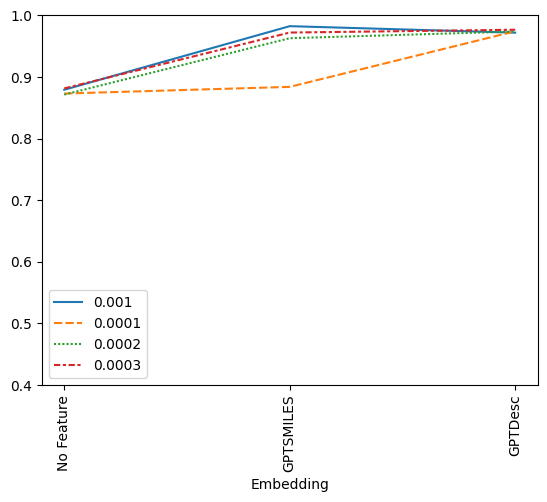

In [59]:
AUC.index=AUC['Embedding']
AUC_edited=AUC.drop(['Embedding'],axis=1)
    
ax=sns.lineplot(data=AUC_edited)
ax.set_ylim(0.4, 1)
ax.tick_params(axis='x', rotation=90)

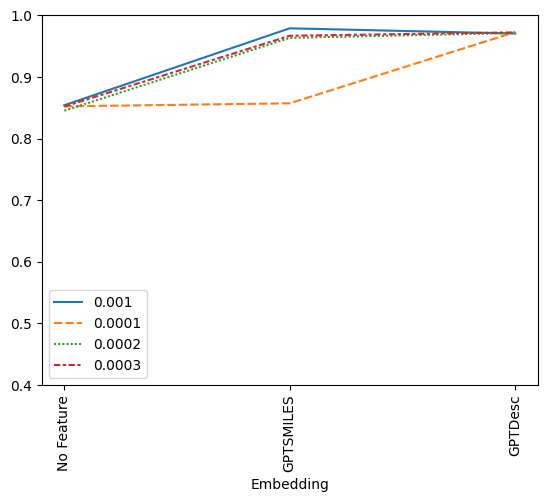

In [60]:
PR.index=AUC['Embedding']
PR_edited=PR.drop(['Embedding'],axis=1)
ax=sns.lineplot(data=PR_edited)
ax.set_ylim(0.4, 1)
ax.tick_params(axis='x', rotation=90)

## Example model prediction

In [144]:
# Example: Get predictions for the first 10 test edges
edge_indices = test_data.edge_label_index[:, :10]  # shape: [2, N]
model.eval()
with torch.no_grad():
    preds = model(test_data.x, test_data.edge_index, edge_indices)
print("Predicted scores:", preds)

Predicted scores: tensor([0.5498, 0.3549, 0.6188, 0.7040, 1.4635, 0.7476, 0.4047, 0.6212, 0.4754,
        0.0965])


In [145]:
def ids_to_drug_names(edge_index_tensor):
    # edge_index_tensor: shape [2, N]
    src_names = [id_node_map[idx.item()] for idx in edge_index_tensor[0]]
    dst_names = [id_node_map[idx.item()] for idx in edge_index_tensor[1]]
    return list(zip(src_names, dst_names))

# Usage:
edge_names = ids_to_drug_names(test_data.edge_index)
print(edge_names[:5])  # Print first 5 edge name pairs

[('DB00813', 'DB01234'), ('DB00177', 'DB01351'), ('DB01021', 'DB01100'), ('DB00193', 'DB00543'), ('DB00248', 'DB00875')]


In [146]:
labels = test_data.edge_label[:10]
print("True labels:", labels)
print("Predicted scores:", preds)

True labels: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
Predicted scores: tensor([0.5498, 0.3549, 0.6188, 0.7040, 1.4635, 0.7476, 0.4047, 0.6212, 0.4754,
        0.0965])
